# <span style="color: yellow;">Master Notebook</span>

This notebook contains our entire project, and should be capable of running from start to end without issue.  It has three main sections - one for our application of algorithms to the pretrained ResNet50, one for ResNet 18, and one for ResNet10t.  In each section, there will be sub-sections for each compression algorithm, and the results will be plotted at the end on a Pareto front.

Please paste your functions applying your compression technique in the appropriate section.  The final deliverable is a <ins>Pareto Front</ins> graph, so what you need to output from your model is its <ins>% size reduction</ins> (how much you decreased parameters) and <ins>F1 accuracy</ins> at that size.

**Table of Contents:**
1. <ins>Data Preparation:</ins> this section pulls the necessary dataset from huggingface and instantiates a pytorch dataset/loaders
2. Application of algorithms to ResNet50
3. Application of algorithms to ResNet18
4. Application of algorithms to ResNet10t

Within each of these application sections, there will be sub-sections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [1]:
import os
cwd = os.getcwd()
new = os.path.join(cwd, 'scalable')
os.chdir(new)
os.getcwd()

'/home/epoc2/scalable'

In [2]:
# first we just ensure we are working in the right folder
import os
target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/epoc2/scalable/CS6423_knowledge_distillation_project


## <span style="color: yellow;">1. Data Preparation</span>

This code downloads the dataset and pretrained models from HuggingFace and does a bit of cleaning. You will need to put a HF token with access to the required repositories into the first cell:

In [9]:
# Fiachra - code that downloads the dataset and organizes the csv.
from huggingface_hub import login
login("your hf token here")

In [10]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os

SAVE_DIR = "data/test_images"
NUM_TEST_IMGS = 10000
os.makedirs(SAVE_DIR, exist_ok=True)

ds = load_dataset(
    "raidium/RadImageNet-VQA",
    "alignment",
    split="val",
    streaming=True
)

subset = ds.shuffle(seed=42, buffer_size=30000).take(NUM_TEST_IMGS)

seen_images = set()
labels_path = "data/labels.csv"

with open(labels_path, "w", encoding="utf-8") as f:
    f.write("filename,pathology,modality,location,label\n")

    for i, row in enumerate(tqdm(subset, desc="Saving unique images", total=NUM_TEST_IMGS)):
        if not isinstance(row, dict):
            continue

        img_id = row.get("id", i)

        if img_id not in seen_images:
            img_filename = f"test_{img_id}.png"
            img_path = os.path.join(SAVE_DIR, img_filename)

            if not os.path.exists(img_path):
                row["image"].save(img_path)

            meta = row.get("metadata", {})
            pathology = meta.get("pathology", "unknown")
            modality = meta.get("modality", "unknown")
            location = meta.get("location", "unknown")
            label = f"{location}_{pathology}".replace(" ", "_")

            f.write(f"{img_filename},{pathology},{modality},{location},{label}\n")
            seen_images.add(img_id)

print(f"\nProcessing Complete!")
print(f"Total Unique Images: {len(seen_images)}")
print(f"Metadata saved to: {labels_path}")

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Saving unique images:   0%|          | 0/10000 [00:00<?, ?it/s]


Processing Complete!
Total Unique Images: 10000
Metadata saved to: data/labels.csv


total number of classes in dataset: 61
total datapoints in dataset: 9936


,filename,pathology,modality,location,label
0,test_0.png,soft_tissue_fluid,mri,ankle foot,ankle_foot_soft_tissue_fluid
1,test_1.png,osseous_disruption,mri,ankle foot,ankle_foot_osseous_disruption
2,test_2.png,chondral_abnormality,mri,ankle foot,ankle_foot_chondral_abnormality
3,test_3.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_
4,test_4.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_


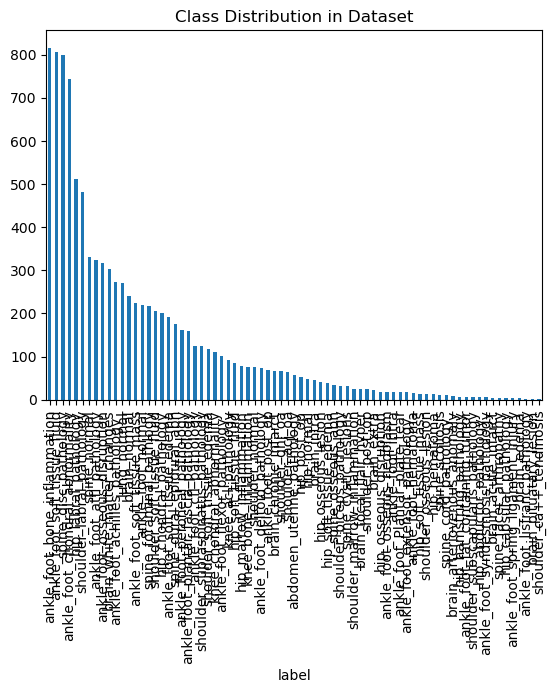

In [11]:
import pandas as pd

test_df = pd.read_csv("data/labels.csv")
label_counts = test_df['label'].value_counts()
label_counts.plot(kind='bar', title='Class Distribution in Dataset')

large_classes = label_counts[label_counts > 10].index
drop_classes_df = test_df[test_df['label'].isin(large_classes)]
num_classes = drop_classes_df.label.value_counts().shape[0]

print(f"total number of classes in dataset: {num_classes}")
print(f"total datapoints in dataset: {len(drop_classes_df)}")
drop_classes_df.to_csv("data/labels.csv", index=False)
df = pd.read_csv('data/labels.csv')

df.head()

Here we prepare the dataset using Fiachra's modules:

In [3]:
# Fiachra - instantiate the dataset/dataloaders through the datasetPrepper
import pandas as pd
from modules.dataset_prepper import datasetPrepper

# sets path variables
pretrained_weights_path = "RadImageNet_weights/resnet50.pth"
dataframe_path = "data/labels.csv"
image_dir = "data/test_images"
model_name = "resnet50_baseline_cpu"

# loads dataset csv
dataframe = pd.read_csv(dataframe_path)
num_classes = dataframe["label"].nunique()

# prepare dataset with datasetPrepper module, print confirmations
data_prep = datasetPrepper(
    dataframe_path="data/labels.csv",
    image_dir="data/test_images",
).prepare(compute_class_weights=True)

print(f"Dataset prepared:")
print(f"  Train samples: {len(data_prep.train_dataset)}")
print(f"  Val samples: {len(data_prep.val_dataset)}")
print(f"  Test samples: {len(data_prep.test_dataset)}")
print(f"  Classes: {len(data_prep.class_names)}")

Dataset prepared:
  Train samples: 7948
  Val samples: 1590
  Test samples: 398
  Classes: 61


# <span style="color: yellow;">Algorithm Application to ResNet50</span>
This section applied all of our KD algorithms to a pretrained ResNet50.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: yellow;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [13]:
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="fiabar/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

'/home/epoc2/scalable/CS6423_knowledge_distillation_project/trained_models'

Here we instantiate the pretrained ResNet50 and run an inference pass for the baseline.

In [4]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet50 = resnet50.to(device)
resnet50.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet50.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet50, "ResNet50 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet50 gpu new...
Running inference...
Our F1 score: 0.49377259670043605
Our total parameters: 23633021


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style="color: yellow;">b. Basic Compression Algorithms</span>

### Initializing our experiment tracker
Here we define a function that can append the results from each model compression algorithm to a dataframe for our Pareto Front visualization.  The tracker has:
* method: the method you used for compression (e.g., LTH, RGP, NAS+KD, etc.)
* base_model: the name of the model you are compressing (e.g., resnet10, resnet18, resnet50) 
* base_size: the number of parameters in the basic model
* compressed_size: the number of parameters in the model you compressed
* f1: the F1 score your compressed model has 

So, after you run each experiment, have something that looks like:

In [6]:
'''
Method = 'Pruning'
Base_Model = 'resnet10'
Base_Model_Parameters = 2012345
New_Model_Parameters = 2002345
F1_Score = 0.8
add_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)
'''

"\nMethod = 'Pruning'\nBase_Model = 'resnet10'\nBase_Model_Parameters = 2012345\nNew_Model_Parameters = 2002345\nF1_Score = 0.8\nadd_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)\n"

In [5]:
# initialize a dataframe we will append our results to
results_df = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet50', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.494


In [6]:
# Code or functions that apply basic pruning
from torch.nn.utils import prune
import copy

def random_prune(model, amount):
    # apply ranodm unstructured pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.random_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'randomized unstructured pruning applied with amount: {amount}')

def magnitude_prune(model, amount):
    # apply random magnitude pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.l1_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'magnitude pruning applied with amount: {amount}')


pruning_amounts = [0.1, 0.25, 0.5, 0.75, 0.9]
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

for amount in pruning_amounts:
    # initialize model copies
    model_random_pruned = copy.deepcopy(resnet50)
    model_magnitude_pruned = copy.deepcopy(resnet50)
    
    # apply prunings and record results
    random_prune(model_random_pruned, amount)
    metrics = evaluator.evaluate_single(model_random_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Random Pruning', 
                   base_model='resnet50',
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])
    
    magnitude_prune(model_magnitude_pruned, amount)
    metrics = evaluator.evaluate_single(model_magnitude_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Magnitude Pruning', 
                   base_model='resnet50', 
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])

display(results_df)

Logged: Random Pruning | Reduction: 10.0% | F1: 0.004


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 10.0% | F1: 0.497


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 24.9% | F1: 0.002


...

/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 74.8% | F1: 0.037


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 89.8% | F1: 0.000
Logged: Magnitude Pruning | Reduction: 89.8% | F1: 0.003


,Method,Base_Model,Size_Reduction_Pct,F1_Score
0,N/A,resnet50,0.0,0.4938
1,Random Pruning,resnet50,9.98,0.0042
2,Magnitude Pruning,resnet50,9.98,0.4967
3,Random Pruning,resnet50,24.94,0.0017
4,Magnitude Pruning,resnet50,24.94,0.4947
5,Random Pruning,resnet50,49.89,0.0
6,Magnitude Pruning,resnet50,49.89,0.4294
7,Random Pruning,resnet50,74.83,0.0
8,Magnitude Pruning,resnet50,74.83,0.0369
9,Random Pruning,resnet50,89.8,0.0002


### Basic Pruning and Quantization

In [9]:
# Code or functions that apply quantization

### Caylum - Lottery Ticket Hypothesis
Sentence or two to explain your method, then your code.

In [10]:
# Caylum - code or functions that apply LTH and output a few datapoints for the Pareto Front
# append to the dataframe as described above

### Kellie - RGP
Code/functions that apply RGP and output a few datapoints for the Pareto Front. RGP iteratively removes the least important convolution filters from ResNet50 using gradient-based importane scorea, sheinking the model in 5 steps from 10% to 50% sparsity. After each pruning step the model is fine-tunes to recover accuracy, trading off model size against F1 score acrpss 5 Pareto front points.

In [7]:
# Kellie - RGP: Rigorous Gradient-based Pruning
# Results loaded from pre-trained checkpoints saved by rgp.ipynb
# Models were trained with iterative structured pruning (DFOT scoring) across
# 5 sparsity levels (10%-50%), fine-tuned for 10 epochs each to recover accuracy.

import os
import torch
import pandas as pd

rgp_checkpoints = {
    '10%': 'trained_models/rgp_step_0.1/rgp_step_0.1_full.pth',
    '20%': 'trained_models/rgp_step_0.2/rgp_step_0.2_full.pth',
    '30%': 'trained_models/rgp_step_0.3/rgp_step_0.3_full.pth',
    '40%': 'trained_models/rgp_step_0.4/rgp_step_0.4_full.pth',
    '50%': 'trained_models/rgp_step_0.5/rgp_step_0.5_full.pth',
}

initial_params = sum(p.numel() for p in resnet50.parameters())
rgp_step_metrics = []

for sparsity, path in rgp_checkpoints.items():
    print(f"Loading RGP {sparsity} model from {path}...")

    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()

    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())

    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    rgp_step_metrics.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# Results summary table
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)

Loading RGP 10% model from trained_models/rgp_step_0.1/rgp_step_0.1_full.pth...
Logged: RGP | Reduction: 4.5% | F1: 0.305
Loading RGP 20% model from trained_models/rgp_step_0.2/rgp_step_0.2_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 7.2% | F1: 0.295
Loading RGP 30% model from trained_models/rgp_step_0.3/rgp_step_0.3_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 10.0% | F1: 0.285
Loading RGP 40% model from trained_models/rgp_step_0.4/rgp_step_0.4_full.pth...


...

Logged: RGP | Reduction: 12.6% | F1: 0.290
Loading RGP 50% model from trained_models/rgp_step_0.5/rgp_step_0.5_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 14.9% | F1: 0.301


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.53,0.3054,86.3,1.09
20%,7.16,0.2954,83.9,1.04
30%,10.01,0.2850,81.3,1.06
40%,12.64,0.2901,79.0,1.04
50%,14.94,0.3012,76.9,1.00


## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>


### Ethan - NAS + KD Algorithm

In [10]:
# Ethan - code or functions that perform NAS + KD

''' search space:
input resolution = [128, 160, 190, 224]
depth = [2, 3, 4]
width = [0.65, 0.8, 1.0, 1.2]
expansion ratio = [3,4,6]
'''

# define a ocnfig class for supernet training
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet50'

        # supernet init params
        self.supernet_res = [128, 160, 190, 224]
        self.supernet_width = [0.65, 0.8, 1.0, 1.2]
        self.supernet_expansion = [1.5, 2.0, 3.0]
        self.supernet_depth = [2, 3, 4]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 3.0
        self.alpha = 0.5
        
        self.saver = 'supernet_resnet50_n'

In [11]:
# Ethan - code or functions that perform NAS + KD
import torch.optim as optim
from torch.optim.lr_scheduler import ConstantLR, CosineAnnealingLR, SequentialLR, LinearLR

# main function to orchestrate supernet training - all the functions will be pulled from knowledge_distillation folder
def main(config, snet, optimizer, scheduler, start_epoch=0):
    #train_loader, search_loader, test_loader = get_data_loaders(data_directory, batch_size = batch_size)
    train_loader = data_prep.train_loader
    val_loader = data_prep.val_loader
    best_val_f1 = 0.0
    
    for epoch in range(start_epoch, config.epochs):        
        stats, phase = train_supernet(snet, 
                                      resnet50,  # this is where we pass teacher
                                      config, 
                                      train_loader, 
                                      optimizer, 
                                      epoch)  # weights distillation loss
        
        # validate every 5 epochs
        if (epoch + 1) % 5 == 0:
            val_stats = validate_supernet(snet, train_loader, val_loader, config)
            print(f"--- VALIDATION Epoch {epoch} ---")
            print(f"MAX Path: Acc {val_stats['MAX']['accuracy']:.2f}% | Loss {val_stats['MAX']['avg_loss']:.4f} | F1: {val_stats['MAX']['f1_macro']:.2f}")
            print(f"MIN Path: Acc {val_stats['MIN']['accuracy']:.2f}% | Loss {val_stats['MIN']['avg_loss']:.4f} | F1: {val_stats['MIN']['f1_macro']:.2f}")
            
            if val_stats['MAX']['f1_macro'] > best_val_f1:
                    print(f"New Best F1! Saving model...")
                    best_val_f1 = val_stats['MAX']['f1_macro']
                    
                    # Save the 'Best' version separately
                    save_path = f"{config.saver}_BEST_f1.pth"
                    
                    # Package it with metadata so you know which epoch it came from
                    checkpoint = {
                        'epoch': epoch,
                        'model_state_dict': snet.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'f1_macro': best_val_f1
                    }
                    torch.save(checkpoint, save_path)
        
        scheduler.step()
        
        # report epoch stats
        print(f"Epoch {epoch} | {phase} | LR: {scheduler.get_last_lr()[0]:.6f} | Loss: {stats['avg_loss']:.4f} | KL (Soft): {stats['avg_kl']:.4f} | Accuracy: {stats['accuracy']:.2f}%  | F1: {stats['f1_macro']:.2f}")
        
        # save every 5 epochs if loss is improving
        if (epoch+1)%5 == 0:
            save_supernet(snet, f'{config.saver}_epoch_{epoch+1}.pth')

In [12]:
from knowledge_distillation.model_init import Supernet_resnet50, save_supernet
from knowledge_distillation.train_loop import DistillationLoss, sample_configs, train_supernet, validate_supernet
# initialize config class
config = SupernetConfig()

# initialize our supernet model
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes)
num_params = sum(p.numel() for p in snet.parameters())
print("Parameters:", num_params)
print("Estimated FP32 size:", num_params * 4 / 1024**3, "GB")  # estimates size of supernet

snet.to(config.device)
# print(Supernet)  # confirm object

# optimizer and LR scheduler
optimizer = optim.SGD(snet.parameters(), lr=0.01, momentum=0.9, weight_decay=4e-5)
scheduler_warmup = ConstantLR(optimizer, factor=1.0, total_iters=config.warmup_epochs) # keep LR constant over warmup epochs
scheduler_cosine = CosineAnnealingLR(optimizer, T_max=(config.epochs - config.warmup_epochs), eta_min=1e-4)  # decay 0.05 -> 0.0001
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine],  milestones=[config.warmup_epochs])

main(config, snet, optimizer, scheduler)

Parameters: 191075391
Estimated FP32 size: 0.7118113003671169 GB
Epoch 0 | warm | LR: 0.010000 | Loss: 7.1891 | KL (Soft): 10.0534 | Accuracy: 5.31%  | F1: 0.04
Epoch 1 | warm | LR: 0.010000 | Loss: 5.6747 | KL (Soft): 7.4816 | Accuracy: 13.05%  | F1: 0.11
Epoch 2 | warm | LR: 0.010000 | Loss: 5.0242 | KL (Soft): 6.4628 | Accuracy: 17.05%  | F1: 0.15
Epoch 3 | warm | LR: 0.010000 | Loss: 4.4930 | KL (Soft): 5.6275 | Accuracy: 20.89%  | F1: 0.18
Recalibrating BN for MAX path...
Recalibrating BN for MIN path...
--- VALIDATION Epoch 4 ---
MAX Path: Acc 15.85% | Loss 3.3740 | F1: 0.12
MIN Path: Acc 16.10% | Loss 3.4184 | F1: 0.12
New Best F1! Saving model...
Epoch 4 | warm | LR: 0.010000 | Loss: 4.2407 | KL (Soft): 5.2378 | Accuracy: 23.19%  | F1: 0.21
Epoch 5 | warm | LR: 0.010000 | Loss: 3.9974 | KL (Soft): 4.8863 | Accuracy: 27.14%  | F1: 0.24
Epoch 6 | warm | LR: 0.010000 | Loss: 3.7539 | KL (Soft): 4.4907 | Accuracy: 29.93%  | F1: 0.27
Epoch 7 | warm | LR: 0.010000 | Loss: 3.5780 | KL

In [16]:
import knowledge_distillation.evolutionary_search as es

# define size limit - about the size of the current resnet50
PARAM_LIMIT = 25.0

# load best supernet weights from training
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location='cuda')
snet.load_state_dict(checkpoint['model_state_dict'])
snet.to('cuda')
snet.eval()

# intialize data loaders
train_loader = data_prep.train_loader
search_loader = data_prep.val_loader

# execute search
print(f"Starting Evolutionary Search")
best_architecture = es.run_evolutionary_search(
    snet, search_loader, train_loader, 'cuda', config,
    generations=10, 
    population_size=30, 
    param_limit=PARAM_LIMIT,    
)

print("\n--- Done Searching ---")
print(f"Final F1: {best_architecture['f1']:.4f}")
print(f"Final Size: {best_architecture['size']:.2f}M")
print(f"Best Config: {best_architecture['config']}")

Starting Evolutionary Search

--- Generation 0 ---


KeyboardInterrupt: 

### Ciara - PWKD
A few sentences to describe your method, then your code

In [14]:
# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

## <span style="color: yellow;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

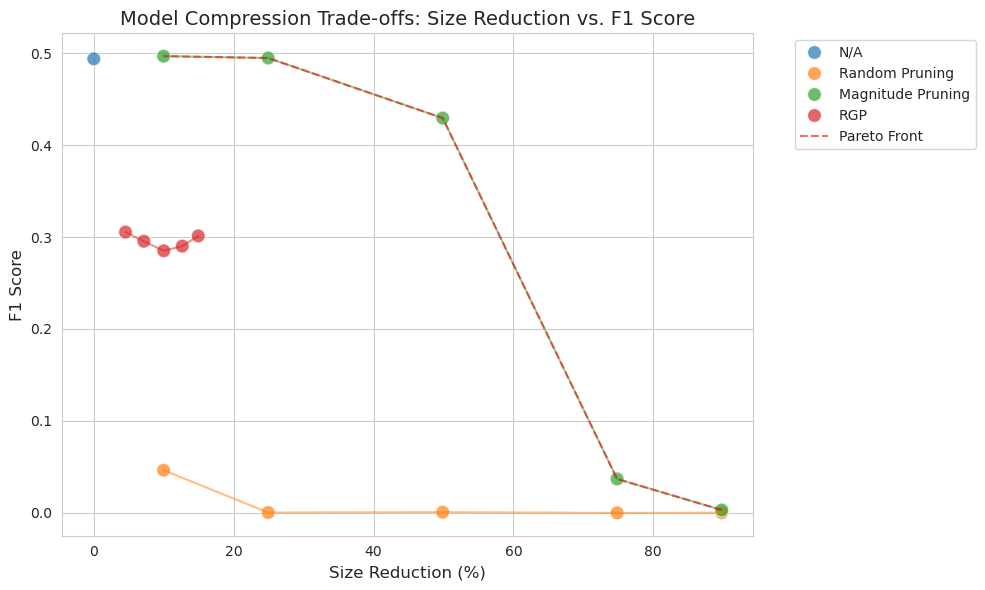

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df)

In [16]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df.to_csv("results_resnet50.csv", mode='a', header=False, index=False)

In [13]:
# <span style="color: yellow;">Algorithm Application to ResNet18</span>
This section applied all of our KD algorithms to a pretrained ResNet18.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

SyntaxError: invalid syntax (3512483351.py, line 2)

In [ ]:
## <span style="color: yellow;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [ ]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet18 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet18_baseline_gpu_new/resnet18_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet18 = resnet18.to(device)
resnet18.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet18.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet18, "ResNet18 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")

In [ ]:
# initialize a dataframe we will append our results to
results_df_resnet18 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df_resnet18, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet18', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

In [ ]:
## <span style="color: yellow;">b. Basic Compression Algorithms</span>

In [ ]:
### Basic Pruning and Quantization

In [ ]:
### Caylum - Lottery Ticket Hypothesis

In [ ]:
### Kellie - RGP

In [ ]:
## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>

In [ ]:
### Ethan - NAS + KD Algorithm

In [ ]:
### Ciara - PWKD

In [ ]:
## <span style="color: yellow;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet18)

In [ ]:
# <span style="color: yellow;">Algorithm Application to ResNet10t</span>
This section applied all of our KD algorithms to a pretrained ResNet10t.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [ ]:
## <span style="color: yellow;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [ ]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet10 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet10t_baseline_gpu_new/resnet10t_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet10 = resnet10.to(device)
resnet10.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet10.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet10, "ResNet10t gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")

In [ ]:
# initialize a dataframe we will append our results to
results_df_resnet10 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df_resnet10, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet10t', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

In [ ]:
## <span style="color: yellow;">b. Basic Compression Algorithms</span>

In [ ]:
### Basic Pruning and Quantization

In [ ]:
### Caylum - Lottery Ticket Hypothesis

In [ ]:
### Kellie - RGP

In [ ]:
## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>

In [ ]:
### Ethan - NAS + KD Algorithm

In [ ]:
### Ciara - PWKD

In [ ]:
## <span style="color: yellow;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet10)

In [ ]:
# Thank you!